In [1]:
from google.colab import files

# Prompt user to upload a folder
uploaded = files.upload()

Saving Ukai(1975-2021).xlsx to Ukai(1975-2021).xlsx


In [3]:
import pandas as pd

df = pd.read_excel("Ukai(1975-2021).xlsx", sheet_name="62255")

Q = df.iloc[:, 3].dropna()

q965 = Q.quantile(0.9915)

print("96.5th percentile =", q965)

96.5th percentile = 4792.825550000001


In [ ]:
import pandas as pd

df = pd.read_excel("Ukai(1975-2021).xlsx")
df["Date"] = pd.to_datetime(
    df[["Year", "Month", "Day"]]
)

print(df.head())

   Year  Month  Day  Q(m3/s)       Date
0  1975      1    1    171.8 1975-01-01
1  1975      1    2      0.0 1975-01-02
2  1975      1    3      0.0 1975-01-03
3  1975      1    4      0.0 1975-01-04
4  1975      1    5     20.0 1975-01-05


In [ ]:
# Basic information
print(df.info())

# First few observations
display(df.head())

# Last few observations
display(df.tail())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Basic statistics of discharge
print("\nDischarge statistics:")
print(df["Q(m3/s)"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16802 entries, 0 to 16801
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Year     16802 non-null  int64         
 1   Month    16802 non-null  int64         
 2   Day      16802 non-null  int64         
 3   Q(m3/s)  16802 non-null  float64       
 4   Date     16802 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 656.5 KB
None


,Year,Month,Day,Q(m3/s),Date
0,1975,1,1,171.8,1975-01-01
1,1975,1,2,0.0,1975-01-02
2,1975,1,3,0.0,1975-01-03
3,1975,1,4,0.0,1975-01-04
4,1975,1,5,20.0,1975-01-05


,Year,Month,Day,Q(m3/s),Date
16797,2020,12,27,72.1,2020-12-27
16798,2020,12,28,0.0,2020-12-28
16799,2020,12,29,0.0,2020-12-29
16800,2020,12,30,0.0,2020-12-30
16801,2020,12,31,13.8,2020-12-31



Missing values:
Year       0
Month      0
Day        0
Q(m3/s)    0
Date       0
dtype: int64
Duplicate rows: 0

Discharge statistics:
count    16802.000000
mean       301.375570
std       1041.159566
min          0.000000
25%          0.000000
50%          0.000000
75%        121.025000
max      29045.800000
Name: Q(m3/s), dtype: float64


In [ ]:
# Number of observations in each year
year_counts = df.groupby("Year").size()

display(year_counts)

print("Minimum observations in a year:", year_counts.min())
print("Maximum observations in a year:", year_counts.max())

,0
Year,
1975,365
1976,366
1977,365
1978,365
1979,365
1980,366
1981,365
1982,365
1983,365


Minimum observations in a year: 365
Maximum observations in a year: 366


In [ ]:
print("Number of years:", df["Year"].nunique())

print("Years present:")
print(sorted(df["Year"].unique()))

Number of years: 46
Years present:
[np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [ ]:
annual_max = (
    df.groupby("Year")["Q(m3/s)"]
      .max()
      .reset_index()
)

annual_max.columns = ["Year", "Peak"]

display(annual_max)

,Year,Peak
0,1975,9499.400000
1,1976,8953.900000
2,1977,6891.200000
3,1978,17441.900000
4,1979,20796.300000
5,1980,4622.900000
6,1981,10695.200000
7,1982,3349.400000
8,1983,6214.700000
9,1984,7816.600000


In [ ]:
threshold = 4622.9

exceed = df[df["Q(m3/s)"] > threshold].copy()

print("Threshold:", threshold, "m³/s")
print("Number of exceedances:", len(exceed))

print(exceed[["Date", "Q(m3/s)"]].head(20))

Threshold: 4622.9 m³/s
Number of exceedances: 153
           Date  Q(m3/s)
91   1975-04-02   9499.4
96   1975-04-07   7723.5
102  1975-04-13   5468.4
371  1976-01-07   8953.9
426  1976-03-02   8053.7
431  1976-03-07   6011.1
432  1976-03-08   7952.9
433  1976-03-09   4757.2
461  1976-04-06   4814.9
462  1976-04-07   6179.3
463  1976-04-08   4756.6
465  1976-04-10   4696.4
757  1977-01-27   6891.2
824  1977-04-04   5537.8
825  1977-04-05   6228.2
1183 1978-03-29   7529.5
1184 1978-03-30   6696.7
1185 1978-03-31   8039.4
1186 1978-04-01  17441.9
1188 1978-04-03   7309.1


In [ ]:
import pandas as pd

# Make sure dates are datetime
exceed['Date'] = pd.to_datetime(exceed['Date'])

# Sort chronologically
exceed = exceed.sort_values('Date').reset_index(drop=True)

# Minimum separation between independent flood peaks
# Use the same interval used by the SFE-IFC procedure
interval = 15;

independent = []

for i in range(len(exceed)):

    # First exceedance is automatically considered
    # as the first independent event
    if len(independent) == 0:
        independent.append(i)
        continue

    last_idx = independent[-1]

    # Number of days since the previously selected peak
    gap = (exceed.loc[i, 'Date'] -
           exceed.loc[last_idx, 'Date']).days

    if gap >= interval:
        # New independent event
        independent.append(i)

    else:
        # Same flood event → retain the larger peak
        if exceed.loc[i, 'Q(m3/s)'] > exceed.loc[last_idx, 'Q(m3/s)']:
            independent[-1] = i

independent_exceed = exceed.loc[independent].reset_index(drop=True)

print("Total exceedances:", len(exceed))
print("Independent flood events:", len(independent_exceed))

print(independent_exceed)

Total exceedances: 153
Independent flood events: 51
    Year  Month  Day       Q(m3/s)       Date
0   1975      4    2   9499.400000 1975-04-02
1   1976      1    7   8953.900000 1976-01-07
2   1976      3    2   8053.700000 1976-03-02
3   1976      4    7   6179.300000 1976-04-07
4   1977      1   27   6891.200000 1977-01-27
5   1977      4    5   6228.200000 1977-04-05
6   1978      4    1  17441.900000 1978-04-01
7   1979      3   13  20796.300000 1979-03-13
8   1981      3   13  10695.200000 1981-03-13
9   1983      3   15   6214.700000 1983-03-15
10  1984      3   22   7816.600000 1984-03-22
11  1986      3   18   6488.500000 1986-03-18
12  1988      3   26   5980.000000 1988-03-26
13  1988      5    6   7974.900000 1988-05-06
14  1989      3   22   6656.100000 1989-03-22
15  1990      2   25   8757.000000 1990-02-25
16  1990      3   26  11858.600000 1990-03-26
17  1991      3    3   8528.400000 1991-03-03
18  1992      3   20   4900.900000 1992-03-20
19  1992      4    6   5081.

In [ ]:
ams = annual_max["Peak"].dropna().reset_index(drop=True)

print("Number of AMS observations:", len(ams))
print(ams.describe())


Number of AMS observations: 46
count       46.000000
mean      8818.827984
std       5667.345491
min       1251.128472
25%       4766.300000
50%       7213.050000
75%      11567.750000
max      29045.800000
Name: Peak, dtype: float64


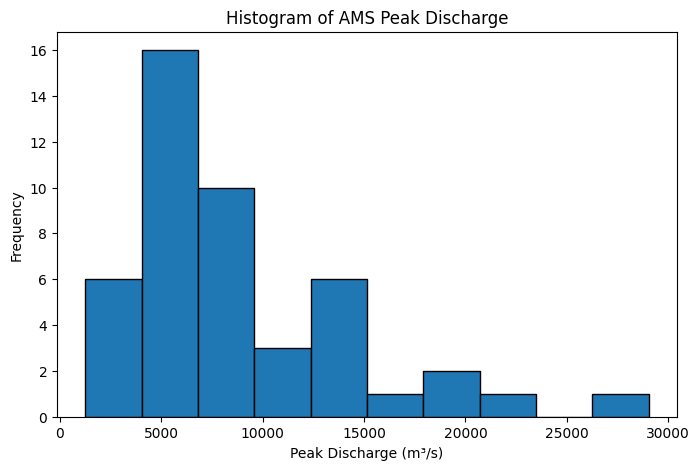

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(ams, bins=10, edgecolor="black")

plt.xlabel("Peak Discharge (m³/s)")
plt.ylabel("Frequency")
plt.title("Histogram of AMS Peak Discharge")

plt.show()

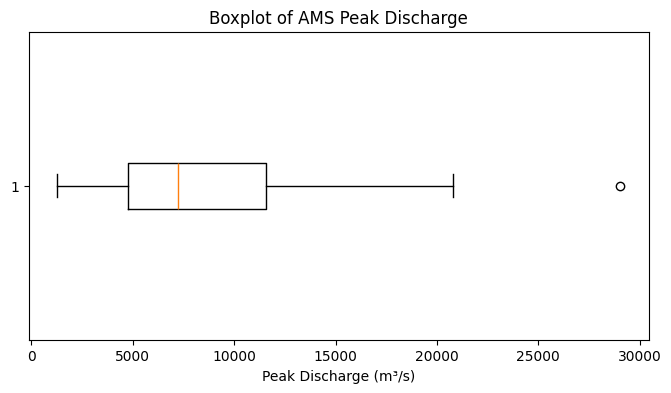

In [ ]:
plt.figure(figsize=(8, 4))

plt.boxplot(ams, vert=False)

plt.xlabel("Peak Discharge (m³/s)")
plt.title("Boxplot of AMS Peak Discharge")

plt.show()


GEV
Parameters: (np.float64(-7.360856879264325), np.float64(1251.5616075430166), np.float64(3.188249196942416))

Gumbel
Parameters: (np.float64(6429.760149817073), 3795.8783419088304)

Lognormal
Parameters: (np.float64(0.5643823962797526), -585.3574268368707, np.float64(8024.1553811153835))

Gamma
Parameters: (np.float64(2.1985824817138377), np.float64(808.6120954652365), np.float64(3643.3547189952146))

Weibull
Parameters: (np.float64(1.1477981958773644), np.float64(2485.9048934953626), np.float64(6700.828147775421))

Pearson III
Parameters: (np.float64(1.348834346160324), np.float64(8818.827937461192), np.float64(5402.227092054755))


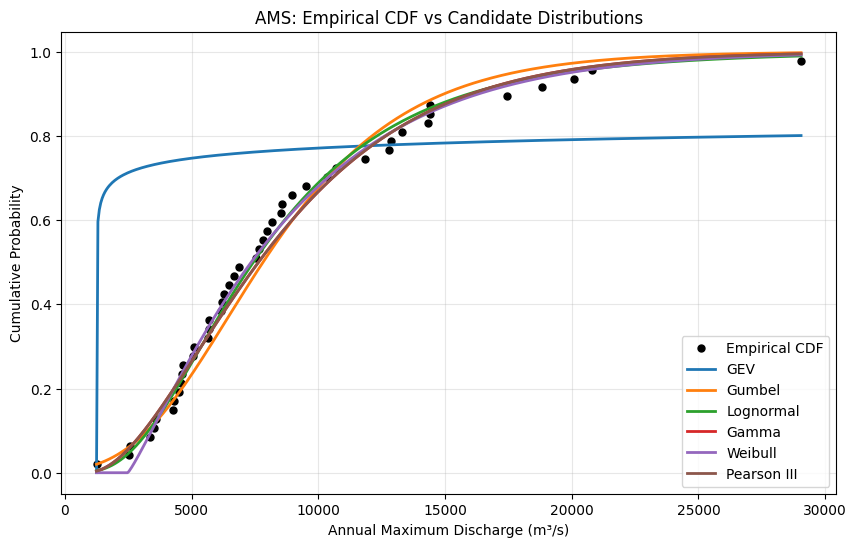

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

# ============================================================
# 2. EMPIRICAL CDF
# ============================================================

ams_sorted = np.sort(ams)

n = len(ams_sorted)

# Weibull plotting position
empirical_cdf = np.arange(1, n + 1) / (n + 1)


# ============================================================
# 3. CANDIDATE DISTRIBUTIONS
# ============================================================

distributions = {
    "GEV": stats.genextreme,
    "Gumbel": stats.gumbel_r,
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Weibull": stats.weibull_min,
    "Pearson III": stats.pearson3
}


# ============================================================
# 4. FIT DISTRIBUTIONS
# ============================================================

fitted_params = {}

for name, distribution in distributions.items():

    try:
        params = distribution.fit(ams)
        fitted_params[name] = params

        print(f"\n{name}")
        print("Parameters:", params)

    except Exception as e:
        print(f"{name} could not be fitted: {e}")


# ============================================================
# 5. PLOT EMPIRICAL CDF + THEORETICAL CDFS
# ============================================================

plt.figure(figsize=(10, 6))

# Empirical CDF
plt.plot(
    ams_sorted,
    empirical_cdf,
    "ko",
    markersize=5,
    label="Empirical CDF"
)


# Theoretical CDFs
x = np.linspace(
    ams_sorted.min(),
    ams_sorted.max(),
    500
)

for name, distribution in distributions.items():

    if name in fitted_params:

        params = fitted_params[name]

        cdf = distribution.cdf(x, *params)

        plt.plot(
            x,
            cdf,
            linewidth=2,
            label=name
        )


plt.xlabel("Annual Maximum Discharge (m³/s)")
plt.ylabel("Cumulative Probability")
plt.title("AMS: Empirical CDF vs Candidate Distributions")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [ ]:
# ============================================================
# 6. AIC AND BIC
# ============================================================

results = []

for name, distribution in distributions.items():

    if name not in fitted_params:
        continue

    params = fitted_params[name]

    # log-likelihood
    loglik = np.sum(distribution.logpdf(ams, *params))

    # number of parameters
    k = len(params)

    # AIC
    aic = 2 * k - 2 * loglik

    # BIC
    bic = k * np.log(len(ams)) - 2 * loglik

    results.append({
        "Distribution": name,
        "LogLikelihood": loglik,
        "AIC": aic,
        "BIC": bic
    })


results_df = pd.DataFrame(results)

results_df = results_df.sort_values("AIC")

print("\nDistribution comparison:")
print(results_df)


Distribution comparison:
  Distribution  LogLikelihood          AIC          BIC
2    Lognormal    -452.507841   911.015682   916.501606
5  Pearson III    -452.824569   911.649138   917.135062
3        Gamma    -452.824569   911.649138   917.135062
1       Gumbel    -454.068568   912.137137   915.794419
0          GEV    -544.579343  1095.158687  1100.644611
4      Weibull           -inf          inf          inf


In [ ]:
# ============================================================
# 7. KOLMOGOROV-SMIRNOV TEST
# ============================================================

ks_results = []

for name, distribution in distributions.items():

    if name not in fitted_params:
        continue

    params = fitted_params[name]

    ks_stat, ks_pvalue = stats.kstest(
        ams,
        distribution.cdf,
        args=params
    )

    ks_results.append({
        "Distribution": name,
        "KS Statistic": ks_stat,
        "KS p-value": ks_pvalue
    })


ks_df = pd.DataFrame(ks_results)

ks_df = ks_df.sort_values("KS Statistic")

print("\nKS goodness-of-fit:")
print(ks_df)


KS goodness-of-fit:
  Distribution  KS Statistic    KS p-value
2    Lognormal      0.058944  9.943430e-01
4      Weibull      0.066997  9.772425e-01
5  Pearson III      0.079641  9.099209e-01
3        Gamma      0.079641  9.099208e-01
1       Gumbel      0.088458  8.333089e-01
0          GEV      0.691487  1.809677e-22


In [ ]:
comparison = results_df.merge(
    ks_df,
    on="Distribution"
)

comparison = comparison.sort_values("AIC")

print(comparison)

  Distribution  LogLikelihood          AIC          BIC  KS Statistic  \
0    Lognormal    -452.507841   911.015682   916.501606      0.058944   
1  Pearson III    -452.824569   911.649138   917.135062      0.079641   
2        Gamma    -452.824569   911.649138   917.135062      0.079641   
3       Gumbel    -454.068568   912.137137   915.794419      0.088458   
4          GEV    -544.579343  1095.158687  1100.644611      0.691487   
5      Weibull           -inf          inf          inf      0.066997   

     KS p-value  
0  9.943430e-01  
1  9.099209e-01  
2  9.099208e-01  
3  8.333089e-01  
4  1.809677e-22  
5  9.772425e-01  


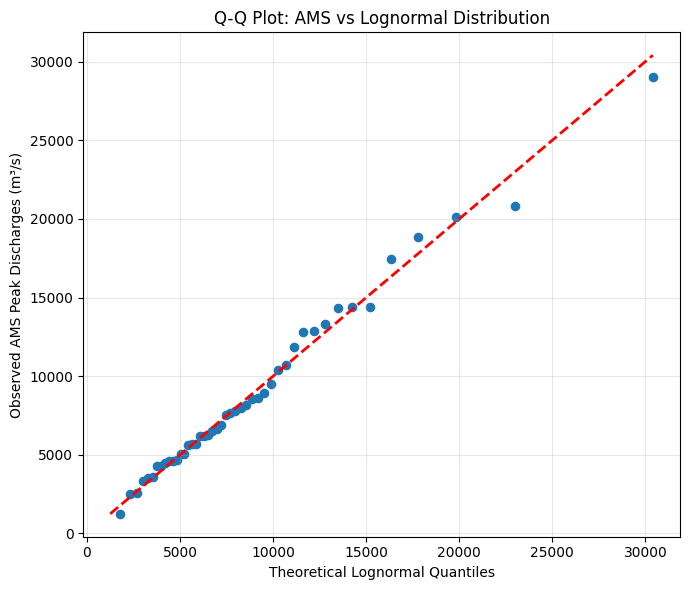

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --------------------------------------------------
# 1. AMS data
# --------------------------------------------------
data = np.asarray(ams)
data = data[np.isfinite(data)]
data = data[data > 0]       # Lognormal requires positive values

# --------------------------------------------------
# 2. Fit Lognormal distribution
# --------------------------------------------------
shape, loc, scale = stats.lognorm.fit(data, floc=0)

# --------------------------------------------------
# 3. Calculate theoretical quantiles
# --------------------------------------------------
n = len(data)

# Empirical plotting positions
p = (np.arange(1, n + 1) - 0.5) / n

# Observed quantiles
observed = np.sort(data)

# Theoretical Lognormal quantiles
theoretical = stats.lognorm.ppf(
    p,
    s=shape,
    loc=loc,
    scale=scale
)

# --------------------------------------------------
# 4. QQ Plot
# --------------------------------------------------
plt.figure(figsize=(7, 6))

plt.scatter(theoretical, observed, s=35)

# 1:1 reference line
min_val = min(theoretical.min(), observed.min())
max_val = max(theoretical.max(), observed.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel("Theoretical Lognormal Quantiles")
plt.ylabel("Observed AMS Peak Discharges (m³/s)")
plt.title("Q-Q Plot: AMS vs Lognormal Distribution")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The Lognormal distribution was selected as the marginal distribution for the AMS peak-discharge series because it provided the best overall fit among the candidate distributions, having the lowest AIC and BIC, the lowest KS statistic, and the highest KS p-value. The Q-Q plot further showed that the observed AMS quantiles were generally in good agreement with the theoretical Lognormal quantiles, although some deviation was observed in the upper tail.

In [ ]:
from scipy.stats import lognorm

given_discharge = 4622.9

# Parameters obtained earlier from your AMS Lognormal fit
p_non_exceedance = lognorm.cdf(
    given_discharge,
    s=shape,
    loc=loc,
    scale=scale
)

p_exceedance = 1 - p_non_exceedance

return_period = 1 / p_exceedance

print(f"Threshold discharge = {given_discharge:.2f} m³/s")
print(f"Non-exceedance probability = {p_non_exceedance:.6f}")
print(f"Exceedance probability = {p_exceedance:.6f}")
print(f"Return period = {return_period:.2f} years")

Threshold discharge = 4622.90 m³/s
Non-exceedance probability = 0.229027
Exceedance probability = 0.770973
Return period = 1.30 years


# univariate POT analysis

In [ ]:
pot_excess = independent_exceed["Q(m3/s)"] - threshold
pot_q = independent_exceed["Q(m3/s)"].values

# Excess above threshold
pot_excess = pot_q - threshold

print("Number of independent POT events:", len(pot_excess))
print("Minimum excess:", pot_excess.min())
print("Maximum excess:", pot_excess.max())

# Check that all are actually above the threshold
print("All exceed threshold:", np.all(pot_q > threshold))

Number of independent POT events: 51
Minimum excess: 45.5
Maximum excess: 24422.9
All exceed threshold: True


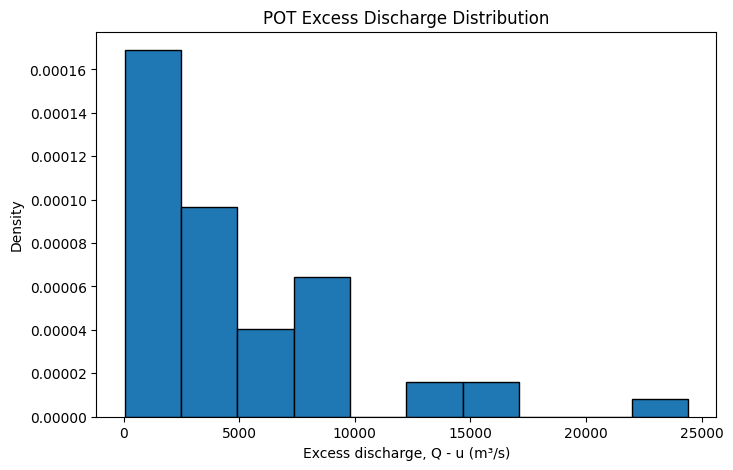

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(pot_excess, bins=10, density=True, edgecolor="black")

plt.xlabel("Excess discharge, Q - u (m³/s)")
plt.ylabel("Density")
plt.title("POT Excess Discharge Distribution")

plt.show()

In [ ]:
from scipy.stats import expon, gamma, lognorm, weibull_min, genpareto

distributions = {
    "Exponential": expon,
    "Gamma": gamma,
    "Lognormal": lognorm,
    "Weibull": weibull_min,
    "Generalized Pareto": genpareto
}

results = []

for name, dist in distributions.items():

    # Fit distribution
    params = dist.fit(pot_excess)

    # Log-likelihood
    loglik = np.sum(dist.logpdf(pot_excess, *params))

    # Number of parameters
    k = len(params)

    # AIC
    aic = 2*k - 2*loglik

    # BIC
    bic = k*np.log(len(pot_excess)) - 2*loglik

    # KS test
    ks_stat, ks_p = __import__("scipy").stats.kstest(
        pot_excess,
        dist.cdf,
        args=params
    )

    results.append([
        name,
        loglik,
        aic,
        bic,
        ks_stat,
        ks_p
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Distribution",
        "LogLikelihood",
        "AIC",
        "BIC",
        "KS Statistic",
        "KS p-value"
    ]
)

results_df = results_df.sort_values("AIC")

print(results_df.to_string(index=False))

      Distribution  LogLikelihood        AIC        BIC  KS Statistic  KS p-value
             Gamma    -478.041166 962.082331 967.877808      0.105759    0.581471
           Weibull    -482.499548 970.999096 976.794573      0.058284    0.991104
       Exponential    -484.552108 973.104215 976.967866      0.055528    0.995034
Generalized Pareto    -484.552114 975.104228 980.899705      0.055432    0.995141
         Lognormal    -486.995089 979.990178 985.785655      0.068736    0.955910


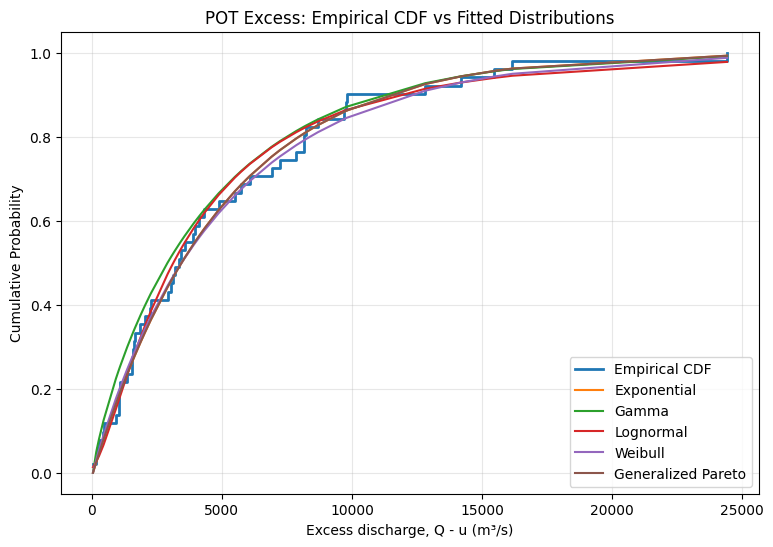

In [ ]:
from scipy.stats import rankdata

# Sort excesses
x = np.sort(pot_excess)

# Empirical CDF
n = len(x)
empirical_cdf = np.arange(1, n + 1) / n

plt.figure(figsize=(9, 6))

# Empirical CDF
plt.step(
    x,
    empirical_cdf,
    where="post",
    label="Empirical CDF",
    linewidth=2
)

# Fitted distributions
for name, dist in distributions.items():

    params = dist.fit(pot_excess)

    theoretical_cdf = dist.cdf(x, *params)

    plt.plot(
        x,
        theoretical_cdf,
        label=name
    )

plt.xlabel("Excess discharge, Q - u (m³/s)")
plt.ylabel("Cumulative Probability")
plt.title("POT Excess: Empirical CDF vs Fitted Distributions")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

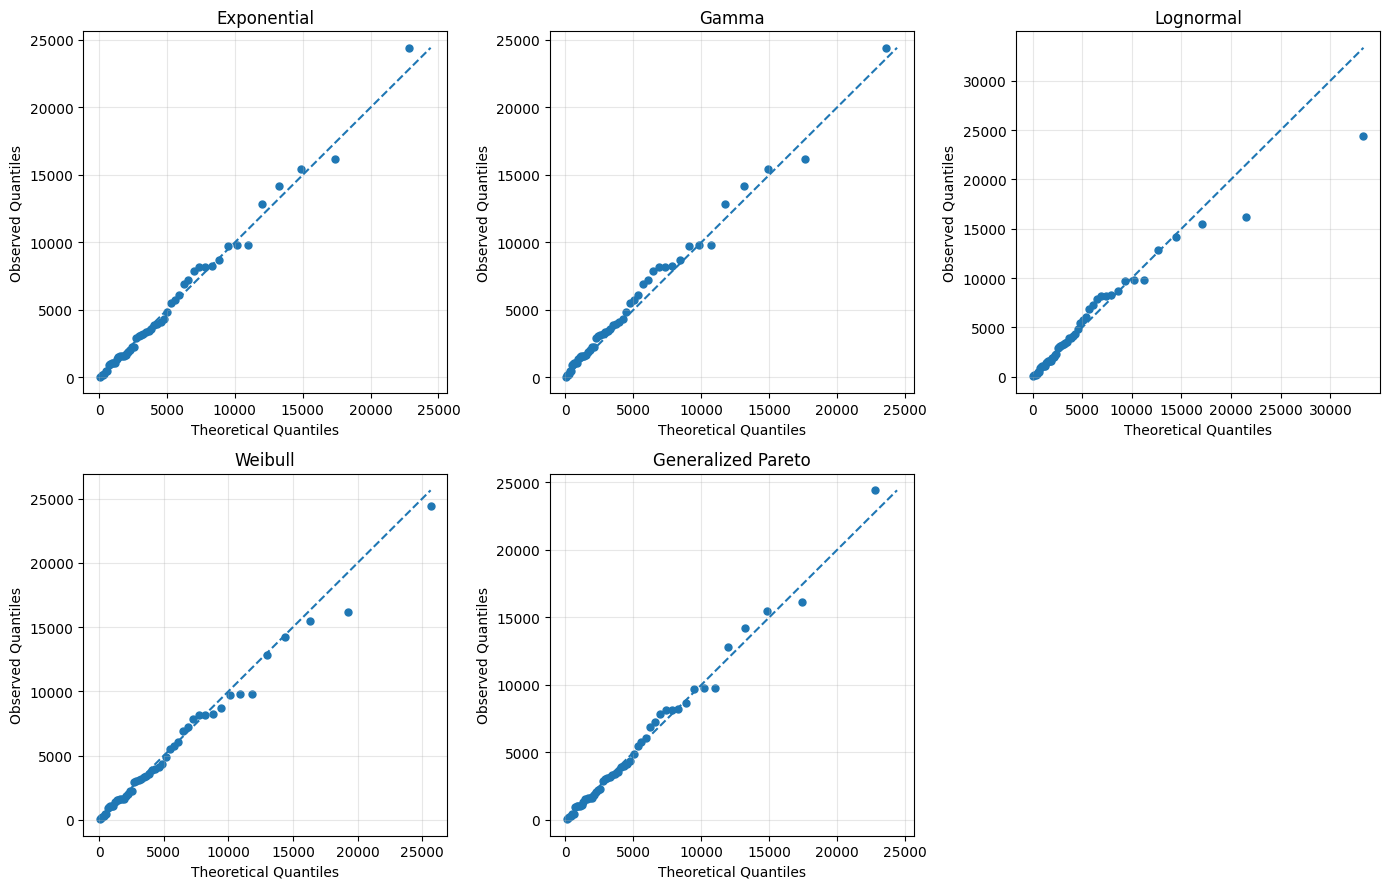

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (name, dist) in enumerate(distributions.items()):

    params = dist.fit(pot_excess)

    # Theoretical probabilities
    p = (np.arange(1, n + 1) - 0.5) / n

    # Theoretical quantiles
    theoretical_q = dist.ppf(p, *params)

    # Observed quantiles
    observed_q = np.sort(pot_excess)

    axes[i].scatter(
        theoretical_q,
        observed_q,
        s=25
    )

    # 45-degree reference line
    min_val = min(theoretical_q.min(), observed_q.min())
    max_val = max(theoretical_q.max(), observed_q.max())

    axes[i].plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Theoretical Quantiles")
    axes[i].set_ylabel("Observed Quantiles")
    axes[i].grid(alpha=0.3)

# Hide unused sixth subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

Gamma produced the lowest AIC and BIC among the candidate distributions. However, the GPD provided a comparable goodness-of-fit and Q–Q performance and is theoretically justified for POT threshold exceedances. The estimated GPD shape parameter was 0.000129, which is effectively zero, indicating that the excess distribution is approximately exponential.

"Among the candidate distributions, the Gamma distribution yielded the lowest AIC and BIC, indicating the best statistical fit according to information criteria. However, the Generalized Pareto distribution provided a comparable Q–Q fit and is theoretically appropriate for modeling threshold exceedances under the POT framework. The fitted GPD had a shape parameter close to zero, indicating behavior close to the exponential distribution."

In [ ]:
from scipy.stats import genpareto

gpd_params = genpareto.fit(pot_excess)

print("GPD parameters:")
print("Shape (xi) =", gpd_params[0])
print("Location =", gpd_params[1])
print("Scale =", gpd_params[2])

GPD parameters:
Shape (xi) = 0.00012897722971692995
Location = 45.49999965263784
Scale = 4917.684949672714


<h1> Bivariate Analysis</h1>

